# Fine-Tuning BLIP on COCO 2014 with LoRA

**Parameter-efficient image captioning** — `Salesforce/blip-image-captioning-base` + LoRA (PEFT) on COCO 2014, designed to run **comfortably on a single Colab T4 (16 GB)**.

This notebook is structured into 15 sections and is meant to be run **cell by cell, top to bottom**.

| | Section |
|---|---|
| 1 | Install Dependencies |
| 2 | Imports |
| 3 | Configuration |
| 4 | Dataset Loading (COCO parsing) |
| 5 | Dataset Class |
| 6 | Data Processing (collator + loaders) |
| 7 | Model Initialization |
| 8 | LoRA Configuration |
| 9 | Training |
| 10 | Validation / Generation |
| 11 | Evaluation Metrics (BLEU 1-4, ROUGE-L, CIDEr, CLIPScore) |
| 12 | Visualization |
| 13 | Inference |
| 14 | Save & Load |
| 15 | Final Results |

> **Expected COCO layout** (set `Config.data_root` to this folder):
> ```
> dataset/
> ├── train2014/
> ├── val2014/
> ├── test2014/
> └── annotations/
>     ├── captions_train2014.json
>     ├── captions_val2014.json
>     └── image_info_test2014.json
> ```


## 1. Install Dependencies

Versions are pinned for reproducibility. They are mutually compatible and use the **current** BLIP / PEFT APIs. If a future Colab image ships an incompatible Torch, bump these to the latest stable releases.

We deliberately use `rouge-score` and `nltk` **directly** instead of `evaluate.load(...)`, because the latter fetches metric scripts from the Hub at runtime and is flaky in shared notebooks. `pycocoevalcap` gives us the standard COCO **CIDEr** scorer (pure-Python, no Java needed for CIDEr).

In [2]:
# If a dependency resolver complains about Colab's pre-installed torch, that is
# usually safe to ignore for these libraries.
!pip install -q "transformers==4.44.2" "datasets==2.21.0" "peft==0.13.2" "accelerate==0.34.2"
!pip install -q "nltk==3.9.1" "rouge-score==0.1.2" "pycocoevalcap==1.2" "safetensors>=0.4.3"
print("Dependencies installed. If versions were already present, this is instant.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 127.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/

## 2. Imports

In [1]:
import os, json, random, time, math, re, gc
from dataclasses import dataclass, field, asdict

import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, PeftModel, set_peft_model_state_dict

import matplotlib.pyplot as plt
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# NLTK tokenizer data (punkt_tab is required by newer NLTK; punkt by older).
for pkg in ["punkt", "punkt_tab"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128 | CUDA available: True
GPU: Tesla T4


## 3. Configuration

All knobs live in one dataclass. The defaults below are tuned for a **Colab T4**.

**Recommended defaults for COCO 2014 on a T4**

| Hyperparameter | Value | Why |
|---|---|---|
| epochs | 3 | LoRA converges fast; early stopping guards over-fit |
| train batch size | 16 | Fits in 16 GB with fp16 + gradient checkpointing |
| grad. accumulation | 2 | Effective batch = 32 |
| learning rate | 5e-4 | LoRA tolerates higher LR than full fine-tuning |
| weight decay | 0.01 | Mild regularization |
| LoRA rank `r` | 16 | Good capacity/cost trade-off for BLIP-base |
| LoRA `alpha` | 32 | `alpha = 2r` scaling, a common, stable choice |
| LoRA `dropout` | 0.05 | Light regularization on adapters |

**Data subset.** Full COCO train2014 is ~83k images / ~414k captions — far more than a T4 demo needs. `max_train_samples` / `max_val_samples` / `max_eval_samples` cap the work so the notebook finishes in a reasonable time. Set them to `None` to use the full splits.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Optionally, update the data_root in the Config if your COCO dataset is in Google Drive.
# cfg = Config(data_root="/content/drive/MyDrive/coco2014"); set_seed(cfg.seed)

Mounted at /content/drive


In [3]:
BASE_DIR = "/content/drive/MyDrive/DeepLearning"

@dataclass
class Config:
    # ---- model / data ----
    model_name: str = "Salesforce/blip-image-captioning-base"
    data_root: str = BASE_DIR                     # train2014/ val2014/ test2014/ annotations/ live here

    # ---- reproducibility ----
    seed: int = 42

    # ---- subset sizes (None = use full split) ----
    max_train_samples: int | None = 5000          # images used for training
    max_val_samples: int | None = 500             # images used for validation LOSS
    max_eval_samples: int | None = 200            # images used for METRIC generation (beam search is slow)

    # ---- training ----
    num_epochs: int = 3
    train_batch_size: int = 16
    eval_batch_size: int = 16
    grad_accum_steps: int = 2
    learning_rate: float = 5e-4
    weight_decay: float = 0.01
    warmup_ratio: float = 0.05
    max_grad_norm: float = 1.0
    early_stopping_patience: int = 2
    min_delta: float = 1e-3
    log_every: int = 50

    # ---- memory ----
    fp16: bool = True
    gradient_checkpointing: bool = True
    num_workers: int = 2

    # ---- tokenization ----
    max_caption_length: int = 40

    # ---- LoRA ----
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05
    # Query/Key/Value projections of the BLIP text decoder (self- + cross-attention).
    lora_target_modules: tuple = ("query", "key", "value")

    # ---- generation (eval / inference) ----
    gen_max_length: int = 30
    num_beams: int = 5

    # ---- output (checkpoints/blip_lora_coco2014 inside your DeepLearning folder) ----
    output_dir: str = os.path.join(BASE_DIR, "checkpoints", "blip_lora_coco2014")

    # ---- derived (filled in __post_init__) ----
    device: str = field(default="cuda", init=False)
    train_image_dir: str = field(default="", init=False)
    val_image_dir: str = field(default="", init=False)
    test_image_dir: str = field(default="", init=False)
    train_ann: str = field(default="", init=False)
    val_ann: str = field(default="", init=False)
    best_dir: str = field(default="", init=False)
    last_dir: str = field(default="", init=False)

    def __post_init__(self):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.train_image_dir = os.path.join(self.data_root, "train2014")
        self.val_image_dir   = os.path.join(self.data_root, "val2014")
        self.test_image_dir  = os.path.join(self.data_root, "test2014")
        self.train_ann = os.path.join(self.data_root, "annotations", "captions_train2014.json")
        self.val_ann   = os.path.join(self.data_root, "annotations", "captions_val2014.json")
        self.best_dir = os.path.join(self.output_dir, "best")
        self.last_dir = os.path.join(self.output_dir, "last")


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


cfg = Config()
set_seed(cfg.seed)
os.makedirs(cfg.output_dir, exist_ok=True)

# Quick sanity check that every path resolves on disk.
print("Device     :", cfg.device)
print("Data root  :", cfg.data_root)
print("Output dir :", cfg.output_dir)
print("-" * 60)
for label, p in [
    ("train images", cfg.train_image_dir),
    ("val images",   cfg.val_image_dir),
    ("test images",  cfg.test_image_dir),
    ("train ann",    cfg.train_ann),
    ("val ann",      cfg.val_ann),
]:
    print(f"  {'OK  ' if os.path.exists(p) else 'MISS'}  {label:12s} -> {p}")

Device     : cuda
Data root  : /content/drive/MyDrive/DeepLearning
Output dir : /content/drive/MyDrive/DeepLearning/checkpoints/blip_lora_coco2014
------------------------------------------------------------
  OK    train images -> /content/drive/MyDrive/DeepLearning/train2014
  OK    val images   -> /content/drive/MyDrive/DeepLearning/val2014
  OK    test images  -> /content/drive/MyDrive/DeepLearning/test2014
  OK    train ann    -> /content/drive/MyDrive/DeepLearning/annotations/captions_train2014.json
  OK    val ann      -> /content/drive/MyDrive/DeepLearning/annotations/captions_val2014.json


### (Optional) Get the COCO data

If you already have COCO somewhere (e.g. Google Drive), just set `cfg.data_root` above and skip this. Otherwise, uncomment **one** option below.

In [4]:
# Sanity check that the expected files exist:
for p in [cfg.train_ann, cfg.val_ann, cfg.train_image_dir, cfg.val_image_dir]:
    print(("OK   " if os.path.exists(p) else "MISS "), p)

OK    /content/drive/MyDrive/DeepLearning/annotations/captions_train2014.json
OK    /content/drive/MyDrive/DeepLearning/annotations/captions_val2014.json
OK    /content/drive/MyDrive/DeepLearning/train2014
OK    /content/drive/MyDrive/DeepLearning/val2014


## 4. Dataset Loading (COCO caption parsing)

A COCO captions file has two relevant arrays:

```json
{ "images":      [{"id": 42, "file_name": "COCO_train2014_000000000042.jpg"}, ...],
  "annotations": [{"image_id": 42, "caption": "a dog on a beach"}, ...] }
```

Each image has **~5 captions**. We build a list of records `{image_id, file_name, captions:[...]}`.

In [ ]:
def load_coco_captions(ann_file: str, image_dir: str, max_images: int | None = None, seed: int = 42):
    "Parse a COCO captions json into a list of {image_id, file_name, captions} records."
    with open(ann_file, "r") as f:
        data = json.load(f)

    id_to_file = {img["id"]: img["file_name"] for img in data["images"]}
    id_to_caps: dict[int, list[str]] = {}
    for ann in data["annotations"]:
        cap = ann["caption"].strip().replace("\n", " ")
        id_to_caps.setdefault(ann["image_id"], []).append(cap)

    records = []
    for image_id, caps in id_to_caps.items():
        fname = id_to_file.get(image_id)
        if fname is None:
            continue
        # Keep only images that actually exist on disk.
        if not os.path.exists(os.path.join(image_dir, fname)):
            continue
        records.append({"image_id": image_id, "file_name": fname, "captions": caps})

    # Deterministic shuffle, then optional truncation.
    rng = random.Random(seed)
    rng.shuffle(records)
    if max_images is not None:
        records = records[:max_images]
    return records


train_records = load_coco_captions(cfg.train_ann, cfg.train_image_dir, cfg.max_train_samples, cfg.seed)
val_records   = load_coco_captions(cfg.val_ann,   cfg.val_image_dir,   cfg.max_val_samples,   cfg.seed)

print(f"Train images: {len(train_records):,}")
print(f"Val   images: {len(val_records):,}")
print("Example record:")
print(json.dumps(train_records[0], indent=2)[:400])

Train images: 5,000
Val   images: 500
Example record:
{
  "image_id": 521200,
  "file_name": "COCO_train2014_000000521200.jpg",
  "captions": [
    "A modern sink and shower stall are visible in this photo.",
    "A white sink in a bathroom next to a wooden bench.",
    "A small sink in a tan public restoom",
    "A bathroom with a sink, shower and bench.",
    "A large bathroom has a shower and sink."
  ]
}


## 5. Dataset Class

**Caption sampling strategy.** Each COCO image has multiple ground-truth captions. During **training** we randomly pick **one caption per image each time the image is drawn** (i.e. per epoch). This is the standard practice in the image-captioning literature: it exposes the model to the full diversity of human captions over the course of training and acts as a free form of data augmentation, while keeping each forward pass to a single target. During **validation loss** we use a fixed caption (the first) for a stable, comparable number; for **metrics** we later compare a generated caption against **all** ground-truth captions (Section 11).

In [ ]:
class COCOCaptionDataset(Dataset):
    def __init__(self, records, image_dir, processor, max_length, train: bool):
        self.records = records
        self.image_dir = image_dir
        self.processor = processor
        self.max_length = max_length
        self.train = train

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        image = Image.open(os.path.join(self.image_dir, rec["file_name"])).convert("RGB")

        # Random caption per epoch for training; fixed for validation loss.
        caption = random.choice(rec["captions"]) if self.train else rec["captions"][0]

        enc = self.processor(
            images=image,
            text=caption,
            return_tensors="pt",
            max_length=self.max_length,
            truncation=True,
            padding=False,          # dynamic padding happens in the collator
        )
        return {
            "pixel_values": enc["pixel_values"][0],   # [3, 384, 384]
            "input_ids": enc["input_ids"][0],         # variable length
        }

## 6. Data Processing (collator + DataLoaders)

**How an (image, caption) pair becomes model input**

1. `BlipProcessor` resizes/normalizes the image → `pixel_values` `[3, 384, 384]`.
2. The same processor tokenizes the caption → `input_ids`.
3. The collator pads `input_ids` to the batch max, builds `attention_mask`, and creates `labels` = `input_ids` with pad positions set to `-100` (ignored by the loss).
4. `BlipForConditionalGeneration` consumes `pixel_values + input_ids + labels` and computes the captioning loss internally (it shifts the labels for next-token prediction).

In [ ]:
def make_collator(processor):
    pad_id = processor.tokenizer.pad_token_id

    def collate(batch):
        pixel_values = torch.stack([b["pixel_values"] for b in batch])
        ids = [b["input_ids"] for b in batch]
        max_len = max(x.size(0) for x in ids)

        input_ids = torch.full((len(ids), max_len), pad_id, dtype=torch.long)
        attention_mask = torch.zeros((len(ids), max_len), dtype=torch.long)
        for i, x in enumerate(ids):
            input_ids[i, : x.size(0)] = x
            attention_mask[i, : x.size(0)] = 1

        labels = input_ids.clone()
        labels[labels == pad_id] = -100      # ignore pad tokens in the loss

        return {
            "pixel_values": pixel_values,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }

    return collate

## 7. Model Initialization

We load the BLIP processor and the base captioning model, then enable **gradient checkpointing** (trades compute for memory) and `enable_input_require_grads()` (needed so gradients flow into the LoRA adapters when checkpointing is on).

In [ ]:
processor = BlipProcessor.from_pretrained(cfg.model_name)
base_model = BlipForConditionalGeneration.from_pretrained(cfg.model_name)

if cfg.gradient_checkpointing:
    try:
        base_model.gradient_checkpointing_enable()
        base_model.enable_input_require_grads()
        print("Gradient checkpointing: ENABLED")
    except Exception as e:
        print("Gradient checkpointing not supported, continuing without it:", e)
        cfg.gradient_checkpointing = False

# Build the data pipeline now that we have a processor.
train_ds = COCOCaptionDataset(train_records, cfg.train_image_dir, processor, cfg.max_caption_length, train=True)
val_ds   = COCOCaptionDataset(val_records,   cfg.val_image_dir,   processor, cfg.max_caption_length, train=False)

collate_fn = make_collator(processor)
train_loader = DataLoader(train_ds, batch_size=cfg.train_batch_size, shuffle=True,
                          collate_fn=collate_fn, num_workers=cfg.num_workers,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=cfg.eval_batch_size, shuffle=False,
                          collate_fn=collate_fn, num_workers=cfg.num_workers,
                          pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
batch = next(iter(train_loader))
print({k: tuple(v.shape) for k, v in batch.items()})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Gradient checkpointing: ENABLED
Train batches: 312 | Val batches: 32
{'pixel_values': (16, 3, 384, 384), 'input_ids': (16, 21), 'attention_mask': (16, 21), 'labels': (16, 21)}


## 8. LoRA Configuration

**Why these target modules?** BLIP captioning = a frozen ViT image encoder feeding a text decoder. We inject LoRA into the **query / key / value** projections of the decoder's attention blocks:

- **Cross-attention Q/K/V** — where text tokens attend to image features. This is the single most important place to adapt, because it controls how strongly and where the caption grounds itself in the picture.
- **Self-attention Q/K/V** — adapts the language modeling to COCO's caption *style* (short, declarative, present tense).

We **freeze the ViT** entirely: COCO photos are in-domain for the pretrained vision encoder, so adapting the decoder is the most parameter-efficient lever. The result is a tiny set of trainable parameters (typically **<2%** of the model), which is exactly what lets this fit on a T4.

In [ ]:
lora_config = LoraConfig(
    r=cfg.lora_r,
    lora_alpha=cfg.lora_alpha,
    lora_dropout=cfg.lora_dropout,
    target_modules=list(cfg.lora_target_modules),
    bias="none",
)

model = get_peft_model(base_model, lora_config)
model.to(cfg.device)

# Report trainable vs total parameters.
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable:,}")
print(f"Total params     : {total:,}")
print(f"Trainable %      : {100 * trainable / total:.3f}%")
print("-" * 50)
model.print_trainable_parameters()

Trainable params : 1,769,472
Total params     : 249,183,548
Trainable %      : 0.710%
--------------------------------------------------
trainable params: 1,769,472 || all params: 249,183,548 || trainable%: 0.7101


## 9. Training

A transparent, fully-controllable training loop with everything the brief asks for:

- **AdamW** optimizer + **weight decay**
- **Cosine LR schedule** with linear warmup
- **fp16** mixed precision (`torch.amp`) + **gradient accumulation** + **gradient checkpointing**
- Per-epoch **validation loss**
- **Early stopping** on validation loss
- **Best checkpoint** saving (LoRA adapter only — a few MB)
- **Resume** support (optimizer / scheduler / scaler / epoch / history)
- Prints **train loss, val loss, LR, epoch progress**

In [ ]:
@torch.no_grad()
def evaluate_loss(model, loader, cfg):
    "Mean per-sample validation loss."
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        batch = {k: v.to(cfg.device) for k, v in batch.items()}
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=cfg.fp16):
            out = model(pixel_values=batch["pixel_values"],
                        input_ids=batch["input_ids"],
                        attention_mask=batch["attention_mask"],
                        labels=batch["labels"])
        bs = batch["input_ids"].size(0)
        total += out.loss.item() * bs
        n += bs
    return total / max(n, 1)


def save_checkpoint(path, model, processor, cfg, optimizer, scheduler, scaler,
                    epoch, global_step, best_val, history):
    os.makedirs(path, exist_ok=True)
    model.save_pretrained(path)        # saves only the LoRA adapter
    processor.save_pretrained(path)
    torch.save({
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": epoch,
        "global_step": global_step,
        "best_val": best_val,
        "history": history,
        "config": asdict(cfg),
    }, os.path.join(path, "training_state.pt"))


def train_model(model, processor, train_loader, val_loader, cfg, resume_from=None):
    device = cfg.device

    optimizer = AdamW([p for p in model.parameters() if p.requires_grad],
                      lr=cfg.learning_rate, weight_decay=cfg.weight_decay)

    steps_per_epoch = math.ceil(len(train_loader) / cfg.grad_accum_steps)
    total_steps = steps_per_epoch * cfg.num_epochs
    warmup_steps = max(1, int(total_steps * cfg.warmup_ratio))
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    scaler = torch.amp.GradScaler("cuda", enabled=cfg.fp16)

    history = {"train_loss": [], "val_loss": [], "lr": []}
    start_epoch, global_step, best_val, patience = 0, 0, float("inf"), 0

    # ---- resume ----
    if resume_from and os.path.exists(os.path.join(resume_from, "training_state.pt")):
        from safetensors.torch import load_file
        adapter_path = os.path.join(resume_from, "adapter_model.safetensors")
        if os.path.exists(adapter_path):
            set_peft_model_state_dict(model, load_file(adapter_path))
        state = torch.load(os.path.join(resume_from, "training_state.pt"), map_location=device)
        optimizer.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"])
        scaler.load_state_dict(state["scaler"])
        start_epoch = state["epoch"] + 1
        global_step = state["global_step"]
        best_val = state["best_val"]
        history = state["history"]
        print(f"Resumed from {resume_from} at epoch {start_epoch}, best_val={best_val:.4f}")

    model.config.use_cache = False     # required with gradient checkpointing
    t0 = time.time()

    for epoch in range(start_epoch, cfg.num_epochs):
        model.train()
        running, seen = 0.0, 0
        optimizer.zero_grad(set_to_none=True)

        for step, batch in enumerate(train_loader):
            batch = {k: v.to(device) for k, v in batch.items()}
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=cfg.fp16):
                out = model(pixel_values=batch["pixel_values"],
                            input_ids=batch["input_ids"],
                            attention_mask=batch["attention_mask"],
                            labels=batch["labels"])
                loss = out.loss / cfg.grad_accum_steps

            scaler.scale(loss).backward()

            bs = batch["input_ids"].size(0)
            running += out.loss.item() * bs
            seen += bs

            is_step = ((step + 1) % cfg.grad_accum_steps == 0) or (step + 1 == len(train_loader))
            if is_step:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], cfg.max_grad_norm)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
                global_step += 1

                if global_step % cfg.log_every == 0:
                    print(f"  epoch {epoch+1} | step {global_step} | "
                          f"loss {running/seen:.4f} | lr {scheduler.get_last_lr()[0]:.2e}")

        train_loss = running / max(seen, 1)
        val_loss = evaluate_loss(model, val_loader, cfg)
        lr_now = scheduler.get_last_lr()[0]
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(lr_now)

        print(f"[Epoch {epoch+1}/{cfg.num_epochs}] "
              f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  lr={lr_now:.2e}")

        # always keep a 'last' checkpoint (for resume)
        save_checkpoint(cfg.last_dir, model, processor, cfg, optimizer, scheduler,
                        scaler, epoch, global_step, best_val, history)

        # best checkpoint + early stopping
        if val_loss < best_val - cfg.min_delta:
            best_val = val_loss
            patience = 0
            save_checkpoint(cfg.best_dir, model, processor, cfg, optimizer, scheduler,
                            scaler, epoch, global_step, best_val, history)
            print(f"  -> new best (val_loss={best_val:.4f}); saved to {cfg.best_dir}")
        else:
            patience += 1
            print(f"  -> no improvement ({patience}/{cfg.early_stopping_patience})")
            if patience >= cfg.early_stopping_patience:
                print("Early stopping triggered.")
                break

    model.config.use_cache = True
    total_time = time.time() - t0
    print(f"\nTraining finished in {total_time/60:.1f} min. Best val_loss={best_val:.4f}")
    return history, total_time, best_val

In [ ]:
# Run training. To resume an interrupted run, pass resume_from=cfg.last_dir.
history, train_time_sec, best_val_loss = train_model(
    model, processor, train_loader, val_loader, cfg, resume_from=cfg.last_dir
)

Resumed from /content/drive/MyDrive/DeepLearning/checkpoints/blip_lora_coco2014/last at epoch 3, best_val=2.2763

Training finished in 0.0 min. Best val_loss=2.2763


## 10. Validation / Caption Generation

`evaluate_loss` (Section 9) already gives a per-epoch validation **loss**. Here we add the **generation** pass used for metric computation: for a set of validation images we generate one caption each (beam search) and keep **all** ground-truth captions as references.

We also reload the **best** adapter so all downstream evaluation/inference uses the best checkpoint rather than the last training state.

In [ ]:
def load_best_adapter(model, cfg):
    "Load the best LoRA adapter weights into the live model in place."
    from safetensors.torch import load_file
    p = os.path.join(cfg.best_dir, "adapter_model.safetensors")
    if os.path.exists(p):
        set_peft_model_state_dict(model, load_file(p))
        print("Loaded best adapter from", cfg.best_dir)
    else:
        print("No best adapter found; using current weights.")
    return model


@torch.no_grad()
def generate_captions(model, processor, records, cfg, max_samples=None):
    "Generate one caption per image; return (predictions, references, records)."
    model.eval()
    model.config.use_cache = True
    device = cfg.device

    items = records if max_samples is None else records[:max_samples]
    preds, refs, sample_records = [], [], []

    for i in range(0, len(items), cfg.eval_batch_size):
        chunk = items[i:i + cfg.eval_batch_size]
        images = [Image.open(os.path.join(cfg.val_image_dir, r["file_name"])).convert("RGB")
                  for r in chunk]
        inputs = processor(images=images, return_tensors="pt").to(device)

        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=cfg.fp16):
            gen = model.generate(pixel_values=inputs["pixel_values"],
                                 max_length=cfg.gen_max_length,
                                 num_beams=cfg.num_beams)
        caps = processor.batch_decode(gen, skip_special_tokens=True)

        for r, c in zip(chunk, caps):
            c = c.strip()
            preds.append(c)
            refs.append(r["captions"])
            sample_records.append({"file_name": r["file_name"],
                                    "gt": r["captions"], "pred": c})
        if (i // cfg.eval_batch_size) % 5 == 0:
            print(f"  generated {min(i + cfg.eval_batch_size, len(items))}/{len(items)}")

    return preds, refs, sample_records


model = load_best_adapter(model, cfg)

# Quick sanity check on 8 validation images.
_p, _r, _rec = generate_captions(model, processor, val_records, cfg, max_samples=8)
for rec in _rec[:4]:
    print("PRED:", rec["pred"])
    print("GT  :", rec["gt"][0])
    print("-" * 40)

Loaded best adapter from /content/drive/MyDrive/DeepLearning/checkpoints/blip_lora_coco2014/best
  generated 8/8
PRED: a bed with a book on top of it in front of a window
GT  : A white bed topped with a book surrounded by large windows.
----------------------------------------
PRED: a woman standing in a kitchen holding a glass of water
GT  : A woman is standing in the kitchen and holding a thermometer.
----------------------------------------
PRED: a man taking a picture of himself in a bathroom mirror
GT  : A man taking his picture in the mirror with a camera.
----------------------------------------
PRED: a couple of people that are on a tennis court
GT  : Spectators watching as competitors play a double tennis game.
----------------------------------------


## 11. Evaluation Metrics

Two complementary families, computed against **all** ground-truth captions per image:

**Text-overlap metrics** (compare the caption to the human references):
- **BLEU-1 … BLEU-4** — n-gram precision (NLTK `corpus_bleu`, method-1 smoothing).
- **ROUGE-L** — longest-common-subsequence F-measure (`rouge_score`); **max over references** per image, then averaged.
- **CIDEr** — TF-IDF-weighted n-gram consensus (official COCO `pycocoevalcap` scorer), designed specifically for captioning.

**Image-aware metric** (reference-free; looks at the actual picture):
- **CLIPScore** — `2.5 · max(cos(CLIP_text(caption), CLIP_image(image)), 0)` using CLIP ViT-B/32. It rewards captions that *describe the image*, regardless of wording, so it catches fluent-but-wrong (hallucinated) captions that text-overlap metrics can miss.
- **RefCLIPScore** — harmonic mean of CLIPScore and the candidate's CLIP-text similarity to the references; bridges image-grounding and reference agreement in one number.

> BLEU and CLIPScore are deliberately reported **together**: BLEU measures phrasing match to humans, CLIPScore measures grounding in the image. When they disagree, that divergence is itself a useful signal.
>
> **Note:** the first CLIPScore call downloads CLIP ViT-B/32 (~600 MB) from the Hub. It fits alongside BLIP on a T4.

In [ ]:
def _tokenize(s: str):
    "Lowercase, drop punctuation, whitespace-split — consistent across all metrics."
    return re.sub(r"[^\w\s]", " ", s.lower()).split()


def compute_bleu(preds, refs):
    list_refs = [[_tokenize(r) for r in rs] for rs in refs]
    hyps = [_tokenize(p) for p in preds]
    smooth = SmoothingFunction().method1
    weight_sets = {
        "BLEU-1": (1.0, 0.0, 0.0, 0.0),
        "BLEU-2": (0.5, 0.5, 0.0, 0.0),
        "BLEU-3": (1/3, 1/3, 1/3, 0.0),
        "BLEU-4": (0.25, 0.25, 0.25, 0.25),
    }
    return {name: corpus_bleu(list_refs, hyps, weights=w, smoothing_function=smooth)
            for name, w in weight_sets.items()}


def compute_rouge_l(preds, refs):
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    vals = []
    for p, rs in zip(preds, refs):
        best = max(scorer.score(r, p)["rougeL"].fmeasure for r in rs)
        vals.append(best)
    return sum(vals) / max(len(vals), 1)


def compute_cider(preds, refs):
    try:
        from pycocoevalcap.cider.cider import Cider
    except Exception as e:
        print("CIDEr unavailable (pycocoevalcap import failed):", e)
        return None
    gts = {i: [" ".join(_tokenize(r)) for r in rs] for i, rs in enumerate(refs)}
    res = {i: [" ".join(_tokenize(p))] for i, p in enumerate(preds)}
    score, _ = Cider().compute_score(gts, res)
    return float(score)


_CLIP_CACHE = {}

def _get_clip(cfg, name="openai/clip-vit-base-patch32"):
    "Load CLIP once and cache it (downloads ~600 MB on first call)."
    if "model" not in _CLIP_CACHE:
        from transformers import CLIPModel, CLIPProcessor
        _CLIP_CACHE["model"] = CLIPModel.from_pretrained(name).to(cfg.device).eval()
        _CLIP_CACHE["proc"] = CLIPProcessor.from_pretrained(name)
    return _CLIP_CACHE["model"], _CLIP_CACHE["proc"]


@torch.no_grad()
def compute_clipscore(preds, refs, sample_records, image_dir, cfg, w=2.5, batch_size=64):
    "CLIPScore (image-aware) and RefCLIPScore. Returns a dict of mean scores."
    try:
        clip_model, clip_proc = _get_clip(cfg)
    except Exception as e:
        print("CLIPScore unavailable (CLIP load failed):", e)
        return {"CLIPScore": None, "RefCLIPScore": None}

    device = cfg.device
    clip_s_per_sample, ref_s_per_sample = [], []

    for i in range(0, len(preds), batch_size):
        files = [r["file_name"] for r in sample_records[i:i + batch_size]]
        images = [Image.open(os.path.join(image_dir, f)).convert("RGB") for f in files]
        cand = preds[i:i + batch_size]

        # Image embeddings (normalized).
        img_in = clip_proc(images=images, return_tensors="pt").to(device)
        img_feat = clip_model.get_image_features(**img_in)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

        # Candidate-caption embeddings (normalized).
        txt_in = clip_proc(text=cand, return_tensors="pt", padding=True, truncation=True).to(device)
        cand_feat = clip_model.get_text_features(**txt_in)
        cand_feat = cand_feat / cand_feat.norm(dim=-1, keepdim=True)

        # CLIPScore = 2.5 * max(cos(image, caption), 0).
        img_cos = (img_feat * cand_feat).sum(-1).clamp(min=0)
        clip_s_per_sample.extend((w * img_cos).cpu().tolist())

        # RefCLIPScore reference term: max cos(caption, reference) over references.
        for j, refs_j in enumerate(refs[i:i + batch_size]):
            ref_in = clip_proc(text=refs_j, return_tensors="pt", padding=True, truncation=True).to(device)
            ref_feat = clip_model.get_text_features(**ref_in)
            ref_feat = ref_feat / ref_feat.norm(dim=-1, keepdim=True)
            ref_cos = (cand_feat[j:j + 1] * ref_feat).sum(-1).clamp(min=0).max().item()
            ref_s_per_sample.append(ref_cos)

    clipscore = float(np.mean(clip_s_per_sample))
    # RefCLIPScore = harmonic mean of CLIPScore and the reference similarity, per sample.
    ref_clip = [(2 * cs * rs / (cs + rs)) if (cs + rs) > 0 else 0.0
                for cs, rs in zip(clip_s_per_sample, ref_s_per_sample)]
    return {"CLIPScore": clipscore, "RefCLIPScore": float(np.mean(ref_clip))}


def run_full_evaluation(model, processor, records, cfg):
    preds, refs, sample_records = generate_captions(
        model, processor, records, cfg, max_samples=cfg.max_eval_samples)
    results = {}
    # Text-overlap metrics.
    results.update(compute_bleu(preds, refs))
    results["ROUGE-L"] = compute_rouge_l(preds, refs)
    results["CIDEr"] = compute_cider(preds, refs)
    # Image-aware metrics.
    results.update(compute_clipscore(preds, refs, sample_records, cfg.val_image_dir, cfg))
    return results, sample_records


print(f"Generating + scoring on {cfg.max_eval_samples or len(val_records)} validation images...")
metrics, eval_samples = run_full_evaluation(model, processor, val_records, cfg)
print("\n=== Validation metrics ===")
for k, v in metrics.items():
    print(f"  {k:12s}: {v:.4f}" if v is not None else f"  {k:12s}: n/a")

Generating + scoring on 200 validation images...
  generated 16/200
  generated 96/200
  generated 176/200


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(



=== Validation metrics ===
  BLEU-1      : 0.7600
  BLEU-2      : 0.6027
  BLEU-3      : 0.4697
  BLEU-4      : 0.3654
  ROUGE-L     : 0.5800
  CIDEr       : 1.3512
  CLIPScore   : 0.7521
  RefCLIPScore: 0.8066


## 12. Visualization

Display validation images alongside their ground-truth and generated captions.

In [ ]:
def show_samples(sample_records, image_dir, n=6, cols=2):
    n = min(n, len(sample_records))
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, rec in zip(axes, sample_records[:n]):
        img = Image.open(os.path.join(image_dir, rec["file_name"])).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        gt = rec["gt"][0]
        gt = gt if len(gt) < 70 else gt[:67] + "..."
        ax.set_title(f"GT:   {gt}\nPRED: {rec['pred']}", fontsize=10, loc="left")

    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


show_samples(eval_samples, cfg.val_image_dir, n=6, cols=2)

Output hidden; open in https://colab.research.google.com to view.

## 13. Inference

Reusable functions for single-image and batch captioning, with full control over decoding: `max_length`, `num_beams`, plus sampling (`temperature`, `top_k`, `top_p`). When `do_sample=True`, beam search is disabled (`num_beams=1`) so the sampling parameters take effect.

In [ ]:
@torch.no_grad()
def caption_image(model, processor, image, cfg, max_length=30, num_beams=5,
                  do_sample=False, temperature=1.0, top_k=50, top_p=1.0):
    "Caption a single image (path or PIL.Image)."
    if isinstance(image, str):
        image = Image.open(image).convert("RGB")
    model.eval()
    model.config.use_cache = True
    inputs = processor(images=image, return_tensors="pt").to(cfg.device)

    gen_kwargs = dict(max_length=max_length)
    if do_sample:
        gen_kwargs.update(do_sample=True, num_beams=1,
                          temperature=temperature, top_k=top_k, top_p=top_p)
    else:
        gen_kwargs.update(num_beams=num_beams)

    with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=cfg.fp16):
        out = model.generate(pixel_values=inputs["pixel_values"], **gen_kwargs)
    return processor.decode(out[0], skip_special_tokens=True).strip()


@torch.no_grad()
def caption_images_batch(model, processor, images, cfg, max_length=30, num_beams=5, batch_size=16):
    "Caption a list of images (paths or PIL.Images)."
    model.eval()
    model.config.use_cache = True
    pil = [Image.open(im).convert("RGB") if isinstance(im, str) else im for im in images]

    captions = []
    for i in range(0, len(pil), batch_size):
        chunk = pil[i:i + batch_size]
        inputs = processor(images=chunk, return_tensors="pt").to(cfg.device)
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=cfg.fp16):
            out = model.generate(pixel_values=inputs["pixel_values"],
                                 max_length=max_length, num_beams=num_beams)
        captions.extend(c.strip() for c in processor.batch_decode(out, skip_special_tokens=True))
    return captions


# --- demo on a couple of validation/test images ---
demo_path = os.path.join(cfg.val_image_dir, val_records[0]["file_name"])
print("Beam search :", caption_image(model, processor, demo_path, cfg, num_beams=5))
print("Sampling    :", caption_image(model, processor, demo_path, cfg,
                                     do_sample=True, temperature=0.9, top_k=50, top_p=0.95))

# Run on unseen test2014 images if present.
if os.path.isdir(cfg.test_image_dir):
    test_files = sorted(os.listdir(cfg.test_image_dir))[:4]
    if test_files:
        test_paths = [os.path.join(cfg.test_image_dir, f) for f in test_files]
        for f, cap in zip(test_files, caption_images_batch(model, processor, test_paths, cfg)):
            print(f"{f}: {cap}")

Beam search : a bed with a book on top of it in front of a window
Sampling    : an open window in a bedroom with a view of the woods
COCO_test2014_000000000001.jpg: a police car parked on the side of the road
COCO_test2014_000000000014.jpg: a man standing in front of a street sign
COCO_test2014_000000000016.jpg: a baseball player swinging a bat at a ball
COCO_test2014_000000000027.jpg: a dog sitting in the passenger seat of a car


## 14. Save & Load

Training already saved the **best** LoRA adapter to `cfg.best_dir`. The adapter is only a few MB. To use it later (or in another notebook), load the base model and attach the adapter with `PeftModel.from_pretrained`. Optionally **merge** the adapter into the base weights for deployment.

In [ ]:
# (Re)save the best adapter + processor to a clean folder for portability.
final_dir = os.path.join(cfg.output_dir, "final_adapter")
model.save_pretrained(final_dir)
processor.save_pretrained(final_dir)
print("Saved adapter + processor to:", final_dir)


def load_finetuned_model(adapter_dir, base_model_name=cfg.model_name, device=None, merge=False):
    "Load base BLIP + LoRA adapter for inference."
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    proc = BlipProcessor.from_pretrained(adapter_dir)
    base = BlipForConditionalGeneration.from_pretrained(base_model_name)
    peft_model = PeftModel.from_pretrained(base, adapter_dir)
    if merge:
        peft_model = peft_model.merge_and_unload()   # plain BLIP model, no PEFT dependency
    return peft_model.to(device).eval(), proc


# Sanity check: reload from disk and caption one image.
reloaded_model, reloaded_proc = load_finetuned_model(final_dir, device=cfg.device)
print("Reloaded model caption:",
      caption_image(reloaded_model, reloaded_proc, demo_path, cfg, num_beams=5))
del reloaded_model
gc.collect(); torch.cuda.empty_cache()

Saved adapter + processor to: /content/drive/MyDrive/DeepLearning/checkpoints/blip_lora_coco2014/final_adapter
Reloaded model caption: a bed with a book on top of it in front of a window


## 15. Final Results

A consolidated academic report: parameter counts, training time, and final captioning metrics — plus the loss curves.

In [ ]:
import pandas as pd

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

report_rows = [
    ("Total parameters",       f"{total:,}"),
    ("Trainable parameters",   f"{trainable:,}"),
    ("Trainable %",            f"{100*trainable/total:.3f}%"),
    ("Training time (min)",    f"{train_time_sec/60:.1f}"),
    ("Best validation loss",   f"{best_val_loss:.4f}"),
    ("BLEU-1",                 f"{metrics['BLEU-1']:.4f}"),
    ("BLEU-2",                 f"{metrics['BLEU-2']:.4f}"),
    ("BLEU-3",                 f"{metrics['BLEU-3']:.4f}"),
    ("BLEU-4",                 f"{metrics['BLEU-4']:.4f}"),
    ("ROUGE-L",                f"{metrics['ROUGE-L']:.4f}"),
    ("CIDEr",                  ("n/a" if metrics['CIDEr'] is None else f"{metrics['CIDEr']:.4f}")),
    ("CLIPScore",              ("n/a" if metrics['CLIPScore'] is None else f"{metrics['CLIPScore']:.4f}")),
    ("RefCLIPScore",           ("n/a" if metrics['RefCLIPScore'] is None else f"{metrics['RefCLIPScore']:.4f}")),
]
report_df = pd.DataFrame(report_rows, columns=["Metric", "Value"])

print("=" * 50)
print("  BLIP + LoRA on COCO 2014 — Final Report")
print("=" * 50)
try:
    from IPython.display import display
    display(report_df)
except Exception:
    print(report_df.to_string(index=False))

  BLIP + LoRA on COCO 2014 — Final Report


,Metric,Value
0,Total parameters,"249,183,548"
1,Trainable parameters,"1,769,472"
2,Trainable %,0.710%
3,Training time (min),0.0
4,Best validation loss,2.2763
5,BLEU-1,0.7600
6,BLEU-2,0.6027
7,BLEU-3,0.4697
8,BLEU-4,0.3654
9,ROUGE-L,0.5800


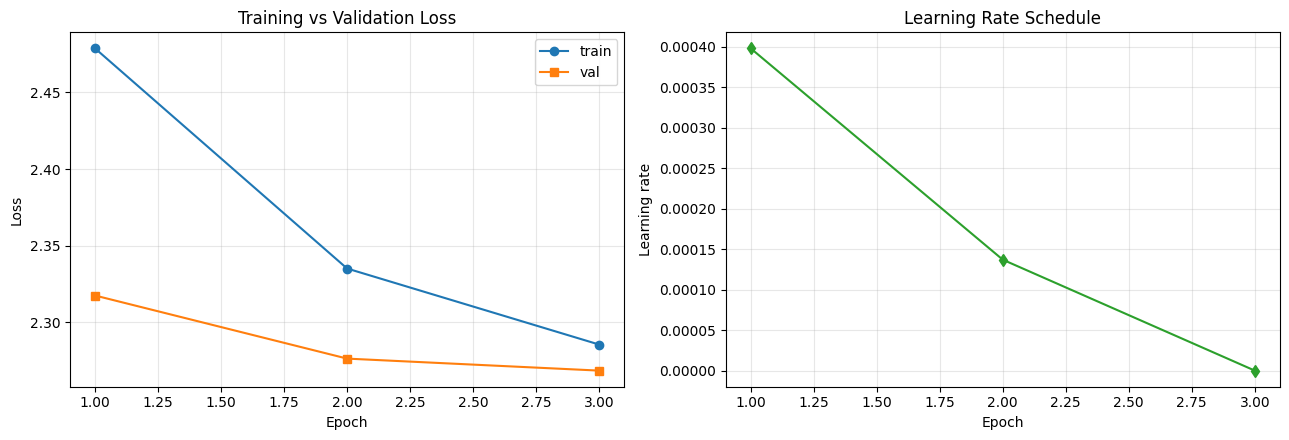

In [ ]:
# Loss curves.
epochs = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(epochs, history["train_loss"], "o-", label="train")
ax1.plot(epochs, history["val_loss"], "s-", label="val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Training vs Validation Loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, history["lr"], "d-", color="tab:green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Learning rate"); ax2.set_title("Learning Rate Schedule")
ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

Loading adapter from: /content/drive/MyDrive/DeepLearning/checkpoints/blip_lora_coco2014/final_adapter
Model ready on cuda


Saving IMG_0874.png to IMG_0874.png


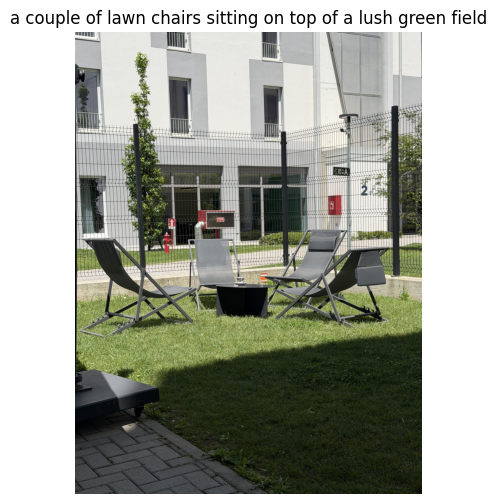

Caption: a couple of lawn chairs sitting on top of a lush green field


In [8]:
# ============================================================================
#  STANDALONE INFERENCE — load saved LoRA checkpoint and caption an image
#  (no training, no dataset, no earlier cells required)
# ============================================================================

# --- 0. Install deps only if missing (fast no-op if already installed) ---
try:
    import transformers, peft  # noqa
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "transformers==4.44.2", "peft==0.13.2",
                    "accelerate==0.34.2", "safetensors>=0.4.3"], check=True)

import os, torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
from peft import PeftModel

# --- 1. Point to your checkpoints folder ------------------------------------
# If your data/checkpoints live on Drive, mount it first:
# from google.colab import drive; drive.mount('/content/drive')
BASE_DIR  = "/content/drive/MyDrive/DeepLearning"
CKPT_ROOT = os.path.join(BASE_DIR, "checkpoints", "blip_lora_coco2014")
BASE_MODEL = "Salesforce/blip-image-captioning-base"

DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
USE_FP16 = (DEVICE == "cuda")

# --- 2. Find the adapter folder (prefers final_adapter > best > last) -------
def find_adapter_dir(root):
    for sub in ["final_adapter", "best", "last", ""]:
        cand = os.path.join(root, sub)
        if os.path.exists(os.path.join(cand, "adapter_config.json")):
            return cand
    raise FileNotFoundError(
        f"No adapter (adapter_config.json) found under {root}. "
        f"Contents: {os.listdir(root) if os.path.exists(root) else 'PATH MISSING'}")

adapter_dir = find_adapter_dir(CKPT_ROOT)
print("Loading adapter from:", adapter_dir)

# --- 3. Load base model + LoRA adapter + processor --------------------------
base = BlipForConditionalGeneration.from_pretrained(BASE_MODEL)
infer_model = PeftModel.from_pretrained(base, adapter_dir).to(DEVICE).eval()
infer_model.config.use_cache = True

# Processor is usually saved next to the adapter; fall back to the base model.
try:
    infer_processor = BlipProcessor.from_pretrained(adapter_dir)
except Exception:
    infer_processor = BlipProcessor.from_pretrained(BASE_MODEL)

print("Model ready on", DEVICE)


# --- 4. Caption one image and display it ------------------------------------
@torch.no_grad()
def caption_and_show(image, max_length=30, num_beams=5,
                     do_sample=False, temperature=0.9, top_k=50, top_p=0.95):
    """image: a file path or a PIL.Image. Shows it and prints the caption."""
    if isinstance(image, str):
        image = Image.open(image).convert("RGB")
    else:
        image = image.convert("RGB")

    inputs = infer_processor(images=image, return_tensors="pt").to(DEVICE)
    gen_kwargs = dict(max_length=max_length)
    if do_sample:
        gen_kwargs.update(do_sample=True, num_beams=1,
                          temperature=temperature, top_k=top_k, top_p=top_p)
    else:
        gen_kwargs.update(num_beams=num_beams)

    with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=USE_FP16):
        out = infer_model.generate(pixel_values=inputs["pixel_values"], **gen_kwargs)
    caption = infer_processor.decode(out[0], skip_special_tokens=True).strip()

    plt.figure(figsize=(6, 6)); plt.imshow(image); plt.axis("off")
    plt.title(caption, fontsize=12, wrap=True); plt.show()
    print("Caption:", caption)
    return caption


# --- 5. Pick ONE input option ------------------------------------------------

# Option A — caption an image by path:
# caption_and_show(os.path.join(BASE_DIR, "val2014", "COCO_val2014_000000000042.jpg"))

# Option B — upload an image from your computer (Colab):
from google.colab import files
uploaded = files.upload()                 # opens a file picker
for fname in uploaded:
    print("=" * 60)
    caption_and_show(fname)               # beam search (deterministic)
    # caption_and_show(fname, do_sample=True)   # sampled variant